In [1]:
"""Laissez-faire (passive-policy) competitive equilibrium, deep-macrofin version.

Neural-network counterpart of the finite-difference `laissez_fair.py`, written in
the style of `full_eff_closed_warm_start.py`.  Nothing is read from .mat files:
the parameters are set below and the frozen policy is derived from the
closed-form efficient steady state.

Policy is passive -- every instrument is held at its efficient steady-state
value rather than responding to the state -- and the government balance sheet is
trivial.  Relative to the efficient model that means:

  * no long bond.  P^L = 1, so sigma^{P^L} = 0 and hence sigma^B = 0.
  * no interest-rate spread.  i = i^R, so every (1-vartheta^L)(i-i^R) term drops.
  * no deposit-velocity block.  The transaction-cost wedge is gone, which
    removes nu and alpha and with them conditions F3 and F4.

What is left is two PDE unknowns (vartheta, pi) and two pointwise unknowns
(sigma^eta, chi) on the same 3D state space (sigma^2, eta, upsilon).

The passive instruments are pinned exactly as in laissez_fair.m, by preserving
three combinations of the efficient steady state,

    mB_ss = i^R + vartheta^L (i - i^R) - s_check
    mv_ss = -s_check - (1-vartheta)(1-vartheta^L)(i - i^R)
    me_ss = s_check + (1 - vartheta/eta)(1-vartheta^L)(i - i^R) + tau^I

and then setting s_check = -mv_ss, i^R = i = mB_ss + s_check, tau^I = me_ss -
s_check.  Written that way each combination is a rearrangement of an efficient
drift, so all three are available in closed form and the trained efficient model
is never needed -- see `efficient_ss_policy`.
"""

import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.optimize import brentq

from deep_macrofin import (Comparator, LossReductionMethod, OptimizerType, PDEModel, set_seeds)

In [2]:
# Core parameter dictionary, taken from model_params.mat -- i.e. the values the
# finite-difference run was actually executed with.  These are NOT the dataclass
# defaults in past_code/full_eff_switch.py, which differ in rho, a, delt, bs,
# varphi and nub, and they are not the values in full_eff_closed_warm_start.py
# either.  varphi in particular is 0.8 here, which moves the efficient eta a
# long way (etap_ss = 0.3833 rather than ~0.30).
params = {
    # --- real block ---
    "rho": 0.07,        # discount rate
    "a": 0.18,          # productivity
    "delta": 0.01,      # depreciation (MATLAB delt)
    "phi": 5.0,         # investment adjustment
    "bs": 0.15,         # mean reversion of \tilde{sigma}^2
    "sig2_ss": 0.5,     # steady-state idiosyncratic risk
    "nus": 0.02,        # diffusion scale of \tilde{sigma}^2
    "varphi": 0.8,      # relative idiosyncratic loading
    "spp": 1.0,         # MATLAB pp
    "lam_I": 0.18 * 0.001,   # type-switching intensity
    "sig2_min": 0.8,    # sig2 domain lower factor (times sig2_ss)
    "sig2_max": 1.2,    # sig2 domain upper factor (times sig2_ss)
    # --- sticky-price block ---
    "e": 10.0,          # demand elasticity (epsilon)
    "kappa": 100.0,     # Rotemberg adjustment cost
    # --- long bond: only the efficient baseline uses it, laissez faire has
    #     P^L = 1 and no coupon ---
    "iL": 0.05,         # perpetuity coupon
    # --- transaction cost: only used to pin the efficient steady state ---
    "cnu": 0.1,         # transaction-cost level
    "nub": 4.0,         # transaction-cost scale
    "cp": 5.0,          # transaction-cost exponent
}

# Derived constants.
params["lam_H"] = params["lam_I"] / 9.0
params["lam"] = params["lam_H"] / (params["lam_I"] + params["lam_H"])
params["b"] = (
    params["a"]
    * (1 + params["rho"] * params["phi"])
    / (params["rho"] * (1 + params["a"] * params["phi"]) * (1 - params["lam"]))
)

# IRF settings, as in the finite-difference code apart from dt_irf: this IRF
# steps sequentially with one network evaluation per step, so MATLAB's 0.01
# would mean 4000 of them.  The drift eigenvalues are O(1), so 0.05 is ample.
dZ = 1.0        # shock size for the impulse response
T_irf = 40.0
dt_irf = 0.05
ap = 5.0        # pre-shock window length

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_PATH = "./models/laissez_fair_closed"
BASELINE_PATH = "./models/laissez_fair_baseline"

In [3]:
# ---------------------------------------------------------------------------
# Static constrained-efficient allocation
#
# Only needed to pin the passive policy: the laissez-faire equilibrium itself
# never touches it.  Same equations as in the efficient model.
# ---------------------------------------------------------------------------
def compute_gamma(eta: torch.Tensor, rho: float, lam_I: float, lam_H: float, lam: float, varphi: float) -> torch.Tensor:
    """Gamma as a function of eta from the efficient allocation FOC."""
    denom = (1 - lam) * eta - lam * varphi**2 * (1 - eta)
    risk_denom = (1 - lam) * eta**2 + lam * varphi**2 * (1 - eta) ** 2
    switching = (
        (1 - lam) * (rho * (1 - eta) + lam_I) / (rho * (1 - eta) ** 2)
        - lam * (rho * eta + lam_H) / (rho * eta**2)
    )
    return switching * risk_denom / denom


def compute_theta_eff(gamma: torch.Tensor, rho: float, phi: float) -> torch.Tensor:
    return gamma / (1 + gamma) * (1 + rho * phi)


def compute_chi_eff(eta: torch.Tensor, lam: float, varphi: float) -> torch.Tensor:
    return (1 - lam) * eta**2 / ((1 - lam) * eta**2 + lam * varphi**2 * (1 - eta) ** 2)


def efficient_eta_residual(eta: torch.Tensor, sig2: torch.Tensor, p: dict) -> torch.Tensor:
    gamma = compute_gamma(eta, p["rho"], p["lam_I"], p["lam_H"], p["lam"], p["varphi"])
    theta = compute_theta_eff(gamma, p["rho"], p["phi"])
    risk_denom = (1 - p["lam"]) * eta**2 + p["lam"] * p["varphi"] ** 2 * (1 - eta) ** 2
    return gamma - (
        (1 - theta) ** 2 * sig2 * p["lam"] * (1 - p["lam"]) * p["varphi"] ** 2
        / (p["rho"] * risk_denom)
    )


def solve_eta_eff(sig2: torch.Tensor, p: dict, tol: float = 1e-10, max_iter: int = 40) -> torch.Tensor:
    """Solve the efficient eta FOC on the eta > lambda branch.

    The root is first found without retaining a growing graph.  Two final
    differentiable Newton corrections recover the exact first and second
    implicit derivatives at a converged root.
    """
    sig2_det = sig2.detach()
    eta = torch.full_like(sig2_det, 0.30)

    for _ in range(max_iter):
        eta_var = eta.detach().requires_grad_(True)
        residual = efficient_eta_residual(eta_var, sig2_det, p)
        derivative = torch.autograd.grad(
            residual, eta_var, grad_outputs=torch.ones_like(residual), create_graph=False,
        )[0]
        step = residual / derivative
        eta = (eta_var - step).detach().clamp(p["lam"] + 1e-5, 1 - 1e-5)
        if torch.max(torch.abs(step)).item() < tol:
            break

    eta = eta.requires_grad_(True)
    for _ in range(2):
        residual = efficient_eta_residual(eta, sig2, p)
        derivative = torch.autograd.grad(
            residual, eta, grad_outputs=torch.ones_like(residual),
            create_graph=True, retain_graph=True,
        )[0]
        eta = eta - residual / derivative
    return eta


def solve_u_planner(p: dict) -> float:
    """Efficient utilization: the positive root of

        a (1 + rho phi) / (rho (1 + a phi u)) = (1 - lam) b'(u),   b'(u) = b u.

    Clearing the denominator leaves a quadratic, so take the root in closed
    form.  The calibration of `b` above makes this exactly 1 for any
    (a, rho, phi, lam), but it moves if `b` is overridden by hand.
    """
    quad = (1 - p["lam"]) * p["rho"] * p["b"] * p["a"] * p["phi"]
    lin = (1 - p["lam"]) * p["rho"] * p["b"]
    const = p["a"] * (1 + p["rho"] * p["phi"])
    if abs(quad) < 1e-12:      # phi = 0: the FOC is linear in u
        return float(const / lin)
    return float((-lin + np.sqrt(lin**2 + 4 * quad * const)) / (2 * quad))


def efficient_levels(sig2: torch.Tensor, p: dict) -> dict[str, torch.Tensor]:
    """Efficient allocation levels at arbitrary sig2."""
    eta = solve_eta_eff(sig2, p)
    gamma = compute_gamma(eta, p["rho"], p["lam_I"], p["lam_H"], p["lam"], p["varphi"])
    theta = compute_theta_eff(gamma, p["rho"], p["phi"])
    chi = compute_chi_eff(eta, p["lam"], p["varphi"])
    u = torch.full_like(sig2, solve_u_planner(p))
    iota = (p["a"] * u * (1 - theta) - p["rho"]) / (1 - theta + p["rho"] * p["phi"])
    growth = torch.log(1 + p["phi"] * iota) / p["phi"] - p["delta"]
    return {"eta": eta, "gamma": gamma, "theta": theta, "chi": chi,
            "u": u, "iota": iota, "g": growth}


def _first_second(value: torch.Tensor, state: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    first = torch.autograd.grad(
        value, state, grad_outputs=torch.ones_like(value),
        create_graph=True, retain_graph=True,
    )[0]
    second = torch.autograd.grad(
        first, state, grad_outputs=torch.ones_like(first),
        create_graph=True, retain_graph=True,
    )[0]
    return first, second


def efficient_ito_objects(sig2: torch.Tensor, p: dict) -> dict[str, torch.Tensor]:
    """Efficient levels and geometric Ito drifts/diffusions."""
    levels = efficient_levels(sig2, p)
    deta, d2eta = _first_second(levels["eta"], sig2)
    dtheta, d2theta = _first_second(levels["theta"], sig2)

    mu_s = p["bs"] * (p["sig2_ss"] - sig2)
    sig_s = p["nus"] * torch.sqrt(sig2) ** p["spp"]

    levels.update({
        "mu_s": mu_s,
        "sig_s": sig_s,
        "mu_eta": (deta * mu_s + 0.5 * d2eta * sig_s**2) / levels["eta"],
        "sig_eta": deta * sig_s / levels["eta"],
        "mu_theta": (dtheta * mu_s + 0.5 * d2theta * sig_s**2) / levels["theta"],
        "sig_theta": dtheta * sig_s / levels["theta"],
    })
    return levels


def efficient_domain(p: dict, padding: float = 0.03) -> tuple[float, float, float, float]:
    """sig2 and eta bounds around the efficient path."""
    sig2_lo = p["sig2_ss"] * p["sig2_min"]
    sig2_hi = p["sig2_ss"] * p["sig2_max"]
    points = torch.tensor([[sig2_lo], [p["sig2_ss"]], [sig2_hi]], dtype=torch.float32, device=DEVICE)
    eta_values = efficient_levels(points, p)["eta"].detach().cpu().numpy().reshape(-1)
    return sig2_lo, sig2_hi, float(eta_values.min() - padding), float(eta_values.max() + padding)


def u_domain(p: dict, halfwidth: float = 0.30) -> list[float]:
    """Utilization box: a relative band around the efficient root.

    The default reproduces the finite-difference grid, u in [0.7, 1.3].  It has
    to be this wide because passive policy moves utilization a long way from the
    efficient root, unlike the efficient solve where u sits at u* by
    construction.
    """
    u_star = solve_u_planner(p)
    return [u_star * (1 - halfwidth), u_star * (1 + halfwidth)]

In [4]:
# ---------------------------------------------------------------------------
# Passive policy
# ---------------------------------------------------------------------------
def solve_velocity_ss(A: float, v: float, denom: float, target: float, p: dict) -> tuple[float, float]:
    """Efficient deposit velocity and vartheta^L at a single point.

    Appendix C.3 can admit several mathematical roots, so bracket every sign
    change and keep the one with nu > 0 and 0 < vartheta^L < 1.
    """
    cfp = lambda x: p["cnu"] * p["cp"] * x ** (p["cp"] - 1) / p["nub"] ** p["cp"]
    residual = lambda nu: nu * cfp(nu) * (nu * A - (1 - v)) / denom - target

    scan = np.linspace(1e-4, 10 * p["nub"], 20000)
    values = residual(scan)
    admissible = []
    for i in np.where(np.sign(values[:-1]) != np.sign(values[1:]))[0]:
        root = brentq(residual, scan[i], scan[i + 1])
        vL = (root * A - (1 - v)) / denom / root
        if root > 0 and 0 < vL < 1:
            admissible.append((root, vL))
    if not admissible:
        raise RuntimeError("no admissible efficient velocity root at the steady state")
    return admissible[0]


def efficient_ss_policy(p: dict) -> dict:
    """Everything about the efficient steady state needed to freeze policy.

    The three combinations the passive policy preserves are rearrangements of
    efficient drifts rather than of the individual instruments:

        mv_ss = mu_v - rho - sigma^H sigma^v
                + (1-v)[(1 - vL + 1/nu) nu^2 c'(nu) + sigma^{tH} sigma]
        me_ss = mu_eta - mu_v + rho - (sigma^eta - sigma^v) sigma^eta
                - (sigma^{tI})^2 + lam_I - lam_H (1-eta)/eta
        mB_ss = mu_B - sigma^B (sigma^eta - sigma^v + sigma^B)

    That is what keeps this file independent of the solved efficient model: the
    individual instruments need P^L, these combinations do not.
    """
    sig2 = torch.tensor([[p["sig2_ss"]]], dtype=torch.float32, device=DEVICE).requires_grad_(True)
    eff = efficient_ito_objects(sig2, p)
    at = lambda key: float(eff[key].detach().cpu().reshape(-1)[0])

    eta, v, chi = at("eta"), at("theta"), at("chi")
    sig_eta, sig_v = at("sig_eta"), at("sig_theta")
    mu_eta, mu_v = at("mu_eta"), at("mu_theta")
    growth, iota = at("g"), at("iota")
    root_sig2 = np.sqrt(p["sig2_ss"])

    sig_B = (1 + p["rho"] * p["phi"]) / (1 - v + p["rho"] * p["phi"]) * sig_v
    alpha = ((eta * sig_eta - (eta - chi) * sig_v) / sig_B - chi + eta) / v + chi
    nu, vL = solve_velocity_ss(
        A=chi - eta + v * (1 - chi),
        v=v,
        denom=(1 - alpha) * v,
        target=sig_eta / (1 - eta) * sig_B,
        p=p,
    )
    cfp_nu = p["cnu"] * p["cp"] * nu ** (p["cp"] - 1) / p["nub"] ** p["cp"]

    sig_H = -eta * sig_eta / (1 - eta)
    sig_tI = (1 - v) * chi / eta * p["varphi"] * root_sig2
    sig_tH = (1 - v) * (1 - chi) / (1 - eta) * root_sig2
    mu_B = (1 + p["rho"] * p["phi"]) / (1 - v + p["rho"] * p["phi"]) * (mu_v - sig_v * (sig_v - sig_B)) + growth

    tau_x = (
        (sig_B - sig_v / (1 - v)) * sig_eta / (1 - eta)
        + (1 - v) * (chi * (p["varphi"] ** 2 * (1 - eta) + eta) - eta) / eta / (1 - eta) * p["sig2_ss"]
        - nu**2 * cfp_nu
    )
    pR = p["rho"] * p["b"] * solve_u_planner(p) * (1 - eta) * (1 + p["phi"] * iota) / (p["a"] * (1 - v))

    return {
        "eta": eta, "v": v, "chi": chi, "sig_eta": sig_eta, "sig_v": sig_v,
        "mu_eta": mu_eta, "mu_v": mu_v, "g": growth, "iota": iota,
        "sig_B": sig_B, "alpha": alpha, "nu": nu, "vL": vL,
        "tau_x": tau_x, "tau_prod": 1 - ((p["e"] - 1) / p["e"]) / pR,
        "mB_ss": mu_B - sig_B * (sig_eta - sig_v + sig_B),
        "mv_ss": mu_v - p["rho"] - sig_H * sig_v
                 + (1 - v) * ((1 - vL + 1 / nu) * nu**2 * cfp_nu + sig_tH * root_sig2),
        "me_ss": mu_eta - mu_v + p["rho"] - (sig_eta - sig_v) * sig_eta - sig_tI**2
                 + p["lam_I"] - p["lam_H"] * (1 - eta) / eta,
    }


def frozen_policy(p: dict, coef: float = 0.0) -> dict:
    """The passive instruments, as constants.

    `coef` is the MATLAB switch: 0 freezes everything at the efficient steady
    state, which is the laissez-faire case.  It is kept as an argument because
    the state-contingent instruments tau_x and vartheta^L would be the ones to
    reintroduce first, but anything other than 0 needs them to become functions
    of sig2 rather than scalars.
    """
    if coef != 0.0:
        raise NotImplementedError(
            "coef > 0 makes tau_x and vL state-contingent; they would have to be "
            "tabulated against sig2 the way full_eff_closed_warm_start does it."
        )
    ss = efficient_ss_policy(p)
    s_check = -ss["mv_ss"]
    interest = ss["mB_ss"] + s_check
    return {
        "s_check": s_check,
        "iR": interest,
        "iT": interest,        # no spread: i = i^R
        "tau_I": ss["me_ss"] - s_check,
        "tau_x": ss["tau_x"],
        "vL": ss["vL"],
        "tau_prod": ss["tau_prod"],
    }

In [10]:
# ---------------------------------------------------------------------------
# Efficient baseline, used only as a warm start
#
# The laissez-faire HJBs are weakly anchored: `Lv = mu_v v` is what is left of
# `rho v = (rho - mu_v) v + Lv` once rho*v cancels off both sides, so it has no
# zeroth-order term at all, and the pi equation only has one of size rf - g,
# about 0.05.  A residual of eps therefore leaves a level error of order
# eps/0.05, which is why solving the laissez-faire system cold lands on the
# wrong branch.  The finite-difference code has the same problem and deals with
# it by starting its value-function iteration from the efficient solution; this
# section does the same thing, by solving the efficient model first on the same
# box and copying its vartheta and pi networks over.
#
# The block below is the efficient model of full_eff_closed_warm_start.py,
# duplicated rather than imported so this file stays standalone.
# ---------------------------------------------------------------------------
def compute_cfp(nu: torch.Tensor, cnu: float, cp: float, nub: float) -> torch.Tensor:
    return cnu * cp * nu ** (cp - 1) / nub**cp


def efficient_steady_state(p: dict) -> tuple[float, float]:
    """Efficient eta and theta at the stochastic steady state."""
    sig2_ss = torch.tensor([[p["sig2_ss"]]], dtype=torch.float32, device=DEVICE)
    levels = efficient_levels(sig2_ss, p)
    return float(levels["eta"].detach().cpu()), float(levels["theta"].detach().cpu())


def compute_policy(SV: torch.Tensor, compute_PI, compute_PL, compute_v, compute_chi,
                   compute_alph, compute_nu, compute_sig_eta) -> torch.Tensor:
    """Policy fields and efficient-path residuals at the sampled sig2.

    Columns are ``[vL, tau_x, i, iR, s_check, tau_I, tau, sigPL_gap, pi_gap,
    v_gap, chi_gap, alph_gap, nu_gap, sig_eta_gap]``.
    """
    p = MODEL_PARAMS
    sig2 = SV[:, 0:1].detach().clone().requires_grad_(True)
    eff = efficient_ito_objects(sig2, p)

    eta, v, chi = eff["eta"], eff["theta"], eff["chi"]
    sig_eta, sig_v = eff["sig_eta"], eff["sig_theta"]
    mu_eta, mu_v, growth = eff["mu_eta"], eff["mu_theta"], eff["g"]

    sig_B = (1 + p["rho"] * p["phi"]) / (1 - v + p["rho"] * p["phi"]) * sig_v
    # Efficient intermediary share of long bonds (alpha = eta^L).
    alpha = ((eta * sig_eta - (eta - chi) * sig_v) / sig_B - chi + eta) / v + chi

    cfp = lambda x: p["cnu"] * p["cp"] * x ** (p["cp"] - 1) / p["nub"] ** p["cp"]
    cfpp = lambda x: p["cnu"] * p["cp"] * (p["cp"] - 1) * x ** (p["cp"] - 2) / p["nub"] ** p["cp"]

    # Appendix C.3 velocity block, reduced to one scalar equation in nu.  It can
    # admit several roots, so run several Newton starts and keep the admissible
    # one with the smallest residual.
    A = chi - eta + v * (1 - chi)
    denom = (1 - alpha) * v
    target = sig_eta / (1 - eta) * sig_B
    safe = lambda x, eps: torch.where(
        torch.abs(x) < eps, torch.where(x >= 0, eps, -eps) * torch.ones_like(x), x
    )
    safe_denom = safe(denom, 1e-8)

    candidates, scores = [], []
    for start_scale in (0.10, 0.25, 0.50, 0.75, 1.00, 1.50):
        nu_try = torch.full_like(v, p["nub"] * start_scale)
        for _ in range(30):
            residual = nu_try * cfp(nu_try) * (nu_try * A - (1 - v)) / safe_denom - target
            derivative = (
                cfp(nu_try) * (nu_try * A - (1 - v)) / safe_denom
                + nu_try * cfpp(nu_try) * (nu_try * A - (1 - v)) / safe_denom
                + nu_try * cfp(nu_try) * A / safe_denom
            )
            nu_try = torch.clamp(nu_try - residual / safe(derivative, 1e-10),
                                 min=1e-5, max=10 * p["nub"])
        vL_try = (nu_try * A - (1 - v)) / safe_denom / nu_try
        final_residual = nu_try * cfp(nu_try) * (nu_try * A - (1 - v)) / safe_denom - target
        admissible = (torch.isfinite(nu_try) & torch.isfinite(vL_try)
                      & (nu_try > 0) & (vL_try > 0) & (vL_try < 1))
        candidates.append(nu_try)
        scores.append(
            torch.abs(final_residual) / (torch.abs(target) + 1e-8)
            + (~admissible).to(final_residual.dtype) * 1e6
            # Deterministic tie-break between equally good admissible roots.
            + 1e-8 * torch.abs(nu_try - p["nub"] / 2)
        )

    best = torch.argmin(torch.stack(scores, dim=0), dim=0, keepdim=True)
    nu_general = torch.gather(torch.stack(candidates, dim=0), 0, best).squeeze(0)
    vL_general = (nu_general * A - (1 - v)) / safe_denom / nu_general

    # Exact limiting solution when alpha = eta^L = 1.
    nu_alpha_one = (1 - v) / safe(A, 1e-8)
    vL_alpha_one = target / (nu_alpha_one**2 * cfp(nu_alpha_one) + 1e-12)
    alpha_one = torch.abs(1 - alpha) < 1e-6
    nu_eff = torch.where(alpha_one, nu_alpha_one, nu_general)
    vL = torch.where(alpha_one, vL_alpha_one, vL_general)
    sig_PL = sig_B / vL

    # Restrict the 3D long-bond price to the efficient path, then differentiate
    # along it.  This is what keeps the policy block coupled to the PDE.
    path_state = torch.cat([sig2, eta, torch.full_like(sig2, solve_u_planner(p))], dim=1)
    PL_eff = compute_PL(path_state)
    pi_eff = compute_PI(path_state)
    dPL, d2PL = _first_second(PL_eff, sig2)
    mu_PL = (dPL * eff["mu_s"] + 0.5 * d2PL * eff["sig_s"] ** 2) / PL_eff
    sig_PL_from_path = dPL * eff["sig_s"] / PL_eff
    sig_PL_gap = sig_PL_from_path - sig_PL

    i_rate = mu_PL + p["iL"] / PL_eff - sig_PL_from_path * (sig_eta + sig_B - sig_v)

    sig_tI = (1 - v) * chi / eta * p["varphi"] * torch.sqrt(sig2)
    sig_tH = (1 - v) * (1 - chi) / (1 - eta) * torch.sqrt(sig2)
    total_variance = (eta * (sig_eta**2 + sig_tI**2)
                      + (1 - eta) * ((eta * sig_eta / (1 - eta)) ** 2 + sig_tH**2))

    tau_x = (
        (sig_B - sig_v / (1 - v)) * sig_eta / (1 - eta)
        + (1 - v) * (chi * (p["varphi"] ** 2 * (1 - eta) + eta) - eta) / eta / (1 - eta) * sig2
        - nu_eff**2 * cfp(nu_eff)
    )
    mu_B = ((1 + p["rho"] * p["phi"]) / (1 - v + p["rho"] * p["phi"])
            * (mu_v - sig_v * (sig_v - sig_B)) + growth)

    iR = (mu_B - i_rate * (vL + (1 - v) * (1 - vL)) + p["rho"] - total_variance
          - sig_eta * sig_PL + chi * (1 - v) * tau_x - mu_v
          - sig_B * (sig_B - sig_v)) / v / (1 - vL)
    s_check = (p["rho"] - total_variance - (1 - v) * (1 - vL) * (i_rate - iR)
               + (sig_B - sig_PL) * sig_eta + chi * (1 - v) * tau_x - mu_v)
    tau_I = (
        mu_eta
        - (1 - eta) * (sig_eta**2 + sig_tI**2 - (eta * sig_eta / (1 - eta)) ** 2 - sig_tH**2
                       - nu_eff**2 * cfp(nu_eff) - (1 - vL) * v / eta * (i_rate - iR))
        - chi * (1 - v) * tau_x + sig_eta * (sig_v - sig_B)
        + p["lam_I"] - p["lam_H"] * (1 - eta) / eta
    )

    # State-dependent monopolistic-firm subsidy (Appendix C.3): it makes pi = 0
    # on the efficient path.
    pR_eff = (p["rho"] * p["b"] * solve_u_planner(p) * (1 - eta)
              * (1 + p["phi"] * eff["iota"]) / (p["a"] * (1 - v)))
    tau_prod = 1 - ((p["e"] - 1) / p["e"]) / pR_eff

    # On the manifold the equilibrium allocation must equal the efficient one.
    # These gaps follow from F1--F4 given the policy fields, but imposing them
    # anchors the 3D solution to the manifold rather than only matching levels.
    return torch.cat(
        [vL, tau_x, i_rate, iR, s_check, tau_I, tau_prod, sig_PL_gap, pi_eff,
         compute_v(path_state) - v,
         compute_chi(path_state) - chi,
         compute_alph(path_state) - alpha,
         compute_nu(path_state) - nu_eff,
         compute_sig_eta(path_state) - sig_eta],
        dim=1,
    )


# Networks the efficient baseline has and the laissez-faire model does not.
# sigma^eta and chi are in the list because laissez faire solves for them
# exactly rather than approximating them (see `compute_inner_lf`).
EFF_ONLY_NETS = ("PL", "alph", "nu", "sig_eta", "chi")


def compute_inner_lf(eta, v, sig2, tau_x, vaux_s, vaux_e, vaux_u, sig_s, a0, a1) -> torch.Tensor:
    """Exact pointwise solution of LF1-LF2 -> ``[sig_eta, chi, |F|_max]``.

    LF1 and LF2 are algebraic in (sigma^eta, chi) at every point, so they can be
    solved to machine precision by Newton instead of being approximated by a
    network and penalised in the loss.  That both removes two loss terms and
    stops the residual floor from being set by an equation that has an exact
    solution -- the point-network version left LF1 at 1e-4, the largest term in
    the objective.

    Thirty detached iterations locate the root, then two differentiable Newton
    maps at the root give exact implicit-function gradients with respect to the
    vartheta network, so the PDE losses still see the right sensitivities.  Same
    construction as `compute_inner` in the efficient model, and the Jacobian is
    the one in inner_loop_lf.m.
    """
    p = MODEL_PARAMS
    varphi = p["varphi"]
    tx = tau_x if torch.is_tensor(tau_x) else torch.full_like(eta, float(tau_x))

    def FJ(z, C):
        et, vv, s2, txs, ves_s, ves_e, ves_u, ss, A0, A1 = C
        se, c = z[:, 0:1], z[:, 1:2]
        sv = ves_e * et * se + ves_s * ss + ves_u * (A0 + A1 * et * se)
        dsv = et * (ves_e + ves_u * A1)
        F1 = et * se + (c - et) * sv
        F2 = (se * (-sv / (1 - vv))
              + (1 - vv) * (c * (et + (1 - et) * varphi**2) - et) / et * s2
              - txs * (1 - et))
        J1 = torch.cat([et + (c - et) * dsv, sv], dim=1)
        J2 = torch.cat([-sv / (1 - vv) - se * dsv / (1 - vv),
                        (1 - vv) * (et + (1 - et) * varphi**2) / et * s2], dim=1)
        return torch.cat([F1, F2], dim=1), torch.stack([J1, J2], dim=1)

    C_live = (eta, v, sig2, tx, vaux_s, vaux_e, vaux_u, sig_s, a0, a1)
    C_det = tuple(x.detach() for x in C_live)
    I2 = torch.eye(2, dtype=eta.dtype, device=eta.device)

    # Start at the efficient allocation: sigma^eta along the efficient path and
    # chi at its closed form for the local eta.
    with torch.enable_grad():
        s = sig2.detach().clone().requires_grad_(True)
        se0 = efficient_ito_objects(s, p)["sig_eta"].detach()
    z = torch.cat([se0, compute_chi_eff(eta.detach(), p["lam"], varphi)], dim=1)

    with torch.no_grad():
        for _ in range(30):
            F, J = FJ(z, C_det)
            z = z - torch.linalg.solve(J + 1e-12 * I2, F.unsqueeze(-1)).squeeze(-1)
    z = z.detach()
    for _ in range(2):
        F, J = FJ(z, C_live)
        z = z - torch.linalg.solve(J + 1e-12 * I2, F.unsqueeze(-1)).squeeze(-1)
    return torch.cat([z, FJ(z, C_live)[0].abs().max(dim=1, keepdim=True).values], dim=1)


LF_INNER_EQS = [
    "alg=compute_inner_lf(eta, v, sig2, tau_x, vaux_s, vaux_e, vaux_u, sig_s, a0, a1)",
    "sig_eta=alg[:, 0:1]",
    "chi=alg[:, 1:2]",
    "F_norm=alg[:, 2:3]",
]


def attach_lr_decay(model: PDEModel, lr_start: float, lr_end: float, num_epochs: int) -> None:
    """Geometric learning-rate decay; the library has no scheduler of its own.

    Chasing the small residuals this model needs does not work at a fixed rate:
    too high and it will not settle, too low and it never leaves the warm start.
    """
    ratio = (lr_end / lr_start) ** (1.0 / max(num_epochs - 1, 1))

    def step(epoch: int = 0, **_):
        for group in model.optimizer.param_groups:
            group["lr"] = lr_start * ratio**epoch

    model.OnTrainingStep += step


def _quiet(fn, *args, **kwargs):
    """Run fn with stdout/stderr captured (progress bars, 'Model loaded', warnings)."""
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        return fn(*args, **kwargs)


def get_efficient_model(model_path, model_size: list[int], state_domain: dict,
                        batch_size: int = 2000, num_epochs: int = 5000,
                        lr: float = 1e-3) -> PDEModel:
    """Solve the efficient model on `state_domain`, to warm-start laissez faire.

    This is only ever used as an initial condition, so it is trained on exactly
    the laissez-faire box rather than the tight one the efficient model would
    normally use.
    """
    eta_ss, _ = efficient_steady_state(MODEL_PARAMS)

    set_seeds(42)
    model = PDEModel("full_eff_baseline",
        config={
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "optimizer_type": OptimizerType.Adam,
            "lr": lr,
            "stacked": True,
        },
    )
    model.set_state(["sig2", "eta", "u"], dict(state_domain))
    model.add_params(MODEL_PARAMS)

    pde_cfg = {"hidden_units": model_size, "batch_jac_hes": True}
    point_cfg = {"hidden_units": model_size, "derivative_order": 0}
    model.add_endog("v", config={**pde_cfg, "positive": True})
    model.add_endog("PL", config={**pde_cfg, "positive": True})
    model.add_endog("pie", config=pde_cfg)
    model.add_endog("sig_eta", config=point_cfg)
    model.add_endog("chi", config=point_cfg)
    model.add_endog("alph", config=point_cfg)
    model.add_endog("nu", config={**point_cfg, "positive": True})
    model.register_functions(MODEL_FUNCS + [compute_policy, compute_cfp])

    model.add_equations([
        "policy=compute_policy(SV,compute_pie, compute_PL, compute_v, compute_chi, compute_alph, compute_nu, compute_sig_eta)",
        "vL=policy[:, 0:1]",
        "tau_x=policy[:, 1:2]",
        "iT=policy[:, 2:3]",
        "iR=policy[:, 3:4]",
        "s_check=policy[:, 4:5]",
        "tau_I=policy[:, 5:6]",
        "tau_prod=policy[:, 6:7]",
        "efficient_sigPL_gap=policy[:, 7:8]",
        "efficient_pi_gap=policy[:, 8:9]",
        "efficient_v_gap=policy[:, 9:10]",
        "efficient_chi_gap=policy[:, 10:11]",
        "efficient_alph_gap=policy[:, 11:12]",
        "efficient_nu_gap=policy[:, 12:13]",
        "efficient_sig_eta_gap=policy[:, 13:14]",
        "sig_s=compute_sig_s(sig2, nus, spp)",
        "iota=compute_iota(v, u, a, rho, phi)",
        "qK=1+phi*iota",
        "qB=v*qK/(1-v)",
        "g=compute_Phi(iota, phi)-delta",
        "pR=rho*compute_bfp(u, b)*(1-eta)*qK/(a*(1-v))",
        "vaux_s=v_Jac[:, 0, 0:1]/v",
        "vaux_e=v_Jac[:, 0, 1:2]/v",
        "vaux_u=v_Jac[:, 0, 2:3]/v",
        "PLaux_s=PL_Jac[:, 0, 0:1]/PL",
        "PLaux_e=PL_Jac[:, 0, 1:2]/PL",
        "PLaux_u=PL_Jac[:, 0, 2:3]/PL",
        "denom=a*phi*v/qB+(1+rho*phi)*vaux_u-(1-v+rho*phi)*vL*PLaux_u",
        "a0=((1-v+rho*phi)*vL*PLaux_s-(1+rho*phi)*vaux_s)/denom*sig_s",
        "a1=((1-v+rho*phi)*vL*PLaux_e-(1+rho*phi)*vaux_e)/denom",
        "S=eta*sig_eta",
        "sig_ups=a0+a1*S",
        "sig_v=vaux_e*S+vaux_s*sig_s+vaux_u*sig_ups",
        "sig_PL=PLaux_e*S+PLaux_s*sig_s+PLaux_u*sig_ups",
        "sig_B=vL*sig_PL",
        "sig_H=-eta/(1-eta)*sig_eta",
        "sig_tI=(1-v)*chi/eta*varphi*sqrt(sig2)",
        "sig_tH=(1-v)*(1-chi)/(1-eta)*sqrt(sig2)",
        "cfpnu=compute_cfp(nu, cnu, cp, nub)",
        "mu_s=-bs*(sig2-sig2_ss)",
        "mu_B=iR+vL*(iT-iR)-s_check+sig_B*(sig_eta-sig_v+sig_B)",
        "mu_qB=mu_B-pie-g",
        "mu_v=rho-s_check+sig_H*sig_v-(1-v)*((1-vL)*(iT-iR)+(1-vL+1/nu)*nu**2*cfpnu+sig_tH*sqrt(sig2))",
        "mu_eta_rate=mu_v+s_check-rho+(1-vL)*(iT-iR)*(1-v/eta)+(sig_eta-sig_v)*sig_eta+sig_tI**2+tau_I-lam_I+lam_H*(1-eta)/eta",
        "MU=eta*mu_eta_rate",
        "mu_PL=iT-iL/PL+sig_PL*(sig_eta+sig_B-sig_v)",
        "MUu=qB/(a*phi*v)*(mu_qB*(1-v+rho*phi)+(1+rho*phi)*(sig_v*(sig_v-sig_B)-mu_v))",
        "sig_N=sig_B-sig_v",
        "mu_N=mu_B-pie-mu_v-sig_v*sig_N",
        "sig_NH=sig_H+sig_N",
        "mu_ome=-eta*mu_eta_rate/(1-eta)",
        "mu_NH=mu_ome+mu_N+sig_H*sig_N",
        "rf=rho+mu_NH-sig_NH**2",
        "SIG_pie=pie_Jac[:, 0, 0:1]*sig_s+pie_Jac[:, 0, 1:2]*S+pie_Jac[:, 0, 2:3]*sig_ups",
        "MU_pie=pie*(rf-MUu/u-g+sig_NH*sig_ups/u)-e/kappa*(pR*(1-tau_prod)-(e-1)/e)+SIG_pie*(sig_NH-sig_ups/u)",
        "Lv=compute_generator(v_Jac, v_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
        "LPL=compute_generator(PL_Jac, PL_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
        "Lpie=compute_generator(pie_Jac, pie_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
    ])

    model.add_endog_equation("eta*sig_eta+(chi-eta)*sig_v+(eta-chi-v*(alph-chi))*vL*sig_PL=0", label="F1")
    model.add_endog_equation(
        "sig_eta*((vL-1)*sig_PL-sig_v/(1-v))+(1-v)*(chi*(eta+(1-eta)*varphi**2)-eta)/eta*sig2-tau_x*(1-eta)=0",
        label="F2",
    )
    model.add_endog_equation("sig_eta*sig_PL-nu**2*cfpnu*(1-eta)=0", label="F3")
    model.add_endog_equation("nu*(1-(1-chi)*(1-v)/(1-eta)-(1-alph)*vL*v/(1-eta))-(1-v)/(1-eta)=0", label="F4")

    model.add_endog_equation("Lv=mu_v*v", label="hjb_v", loss_reduction=LossReductionMethod.MAE)
    model.add_endog_equation("LPL=mu_PL*PL", label="hjb_PL", loss_reduction=LossReductionMethod.MAE)
    model.add_endog_equation("Lpie=MU_pie", label="hjb_pie", loss_reduction=LossReductionMethod.MAE)

    model.add_endog_equation("efficient_sigPL_gap=0", label="efficient_path_sigPL", loss_reduction=LossReductionMethod.MAE)
    model.add_endog_equation("efficient_pi_gap=0", label="efficient_path_pi", loss_reduction=LossReductionMethod.MAE)
    for gap, label in (
        ("efficient_v_gap", "efficient_path_v"),
        ("efficient_chi_gap", "efficient_path_chi"),
        ("efficient_alph_gap", "efficient_path_alph"),
        ("efficient_nu_gap", "efficient_path_nu"),
        ("efficient_sig_eta_gap", "efficient_path_sig_eta"),
    ):
        model.add_endog_equation(f"{gap}=0", label=label, loss_reduction=LossReductionMethod.MAE)

    norm_state = torch.tensor(
        [[MODEL_PARAMS["sig2_ss"], eta_ss, solve_u_planner(MODEL_PARAMS)]],
        dtype=torch.float32, device=model.device,
    )
    model.add_endog_condition("PL", "PL(SV)", {"SV": norm_state}, Comparator.EQ, "1", {},
                              label="efficient_ss_normalization", weight=100.0)

    os.makedirs(model_path, exist_ok=True)
    if not os.path.exists(os.path.join(model_path, "model.pt")):
        model.train_model(model_path, "model.pt", True)
        print(f"efficient baseline: trained {num_epochs} epochs -> {model_path}")
    model.load_model(torch.load(os.path.join(model_path, "model_best.pt"), weights_only=False))
    model.set_state_constraints(dict(state_domain))
    return model

In [11]:
# ---------------------------------------------------------------------------
# 3D equilibrium helpers
# ---------------------------------------------------------------------------
def compute_sig_s(sig2: torch.Tensor, nus: float, spp: float) -> torch.Tensor:
    return nus * torch.sqrt(sig2) ** spp


def compute_iota(v: torch.Tensor, u: torch.Tensor, a: float, rho: float, phi: float) -> torch.Tensor:
    return (a * u - rho / (1 - v)) / (1 + rho * phi / (1 - v))


def compute_Phi(iota: torch.Tensor, phi: float) -> torch.Tensor:
    return torch.log(1 + phi * iota) / phi


def compute_bfp(u: torch.Tensor, b: float) -> torch.Tensor:
    return b * u


def compute_generator(Jac: torch.Tensor, Hess: torch.Tensor,
    mu_s: torch.Tensor, MU: torch.Tensor, MUu: torch.Tensor,
    sig_s: torch.Tensor, S: torch.Tensor, Su: torch.Tensor,
) -> torch.Tensor:
    """Rank-one infinitesimal generator for the single aggregate shock."""
    mu_vec = torch.cat([mu_s, MU, MUu], dim=1)
    sig_vec = torch.cat([sig_s, S, Su], dim=1)
    drift = torch.einsum("bi,boi->bo", mu_vec, Jac)
    diffusion = 0.5 * torch.einsum("bi,boij,bj->bo", sig_vec, Hess, sig_vec)
    return drift + diffusion

In [12]:
# The frozen instruments are registered as parameters, so they can be referred
# to by name in the equations exactly like rho or phi.
MODEL_PARAMS = dict(params)
MODEL_PARAMS.update(frozen_policy(MODEL_PARAMS))

MODEL_FUNCS = [
    compute_sig_s,
    compute_iota,
    compute_Phi,
    compute_bfp,
    compute_generator,
]


def get_model(model_path, model_size: list[int],
              batch_size: int = 2000, num_epochs: int = 5000, lr: float = 1e-3,
              eta_range=None, u_range=None, warm_start_path=None, lr_end=None,
) -> PDEModel:
    """Build, optionally train, and load the laissez-faire 3D model.

    `eta_range` / `u_range` override the default box.  The default is built
    around the efficient path, and the passive equilibrium generally does not
    sit there, so widen it.

    `warm_start_path` points at a trained efficient baseline (see
    `get_efficient_model`) whose vartheta and pi networks are copied in before
    training.  Solving cold does not work -- see the note on that function -- so
    in practice this is always supplied.
    """
    sig2_lo, sig2_hi, eta_lo, eta_hi = efficient_domain(MODEL_PARAMS)
    state_domain = {
        "sig2": [sig2_lo, sig2_hi],
        "eta": list(eta_range) if eta_range is not None else [eta_lo, eta_hi],
        "u": list(u_range) if u_range is not None else u_domain(MODEL_PARAMS),
    }

    set_seeds(42)
    model = PDEModel("laissez_fair_closed",
        config={
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "optimizer_type": OptimizerType.Adam,
            "lr": lr,
            "stacked": True,
        },
    )
    model.set_state(["sig2", "eta", "u"], state_domain)
    model.add_params(MODEL_PARAMS)

    pde_cfg = {"hidden_units": model_size, "batch_jac_hes": True}
    model.add_endog("v", config={**pde_cfg, "positive": True})
    model.add_endog("pie", config=pde_cfg)
    # sigma^eta and chi are not networks: LF1-LF2 are solved exactly pointwise.
    model.register_functions(MODEL_FUNCS + [compute_inner_lf])

    model.add_equations(
    [
        "sig_s=compute_sig_s(sig2, nus, spp)",
        # Market and auxiliary equations.
        "iota=compute_iota(v, u, a, rho, phi)",
        "qK=1+phi*iota",
        "qB=v*qK/(1-v)",
        "g=compute_Phi(iota, phi)-delta",
        "pR=rho*compute_bfp(u, b)*(1-eta)*qK/(a*(1-v))",
        # Elasticities of the PDE unknowns.  P^L = 1 here, so unlike the
        # efficient model there are no PLaux terms anywhere below.
        "vaux_s=v_Jac[:, 0, 0:1]/v",
        "vaux_e=v_Jac[:, 0, 1:2]/v",
        "vaux_u=v_Jac[:, 0, 2:3]/v",
        # Utilization diffusion: sigma^u = a0 + a1 eta sigma^eta.
        "denom=a*phi*v/qB+(1+rho*phi)*vaux_u",
        "a0=-(1+rho*phi)*vaux_s/denom*sig_s",
        "a1=-(1+rho*phi)*vaux_e/denom",
    ]
    # Exact (sigma^eta, chi) at every sampled point, so LF1 and LF2 never enter
    # the loss.  Has to sit here: it consumes a0/a1 and produces sig_eta.
    + LF_INNER_EQS
    + [
        "S=eta*sig_eta",
        "sig_ups=a0+a1*S",
        # Risk loadings.  sigma^B = 0 because there is no long bond.
        "sig_v=vaux_e*S+vaux_s*sig_s+vaux_u*sig_ups",
        "sig_H=-eta/(1-eta)*sig_eta",
        "sig_tI=(1-v)*chi/eta*varphi*sqrt(sig2)",
        "sig_tH=(1-v)*(1-chi)/(1-eta)*sqrt(sig2)",
        # State drifts.  With i = i^R every (1-vL)(i-i^R) term drops out, and
        # with no transaction cost the nu wedge in mu_v drops out too.
        "mu_s=-bs*(sig2-sig2_ss)",
        "mu_v=rho-s_check+sig_H*sig_v-(1-v)*sig_tH*sqrt(sig2)",
        "mu_eta_rate=mu_v+s_check-rho+(sig_eta-sig_v)*sig_eta+sig_tI**2+tau_I-lam_I+lam_H*(1-eta)/eta",
        "MU=eta*mu_eta_rate",
        "mu_B=iR-s_check",
        "mu_qB=mu_B-pie-g",
        "MUu=qB/(a*phi*v)*(mu_qB*(1-v+rho*phi)+(1+rho*phi)*(sig_v*sig_v-mu_v))",
        # Rotemberg inflation drift.
        "sig_N=-sig_v",
        "mu_N=mu_B-pie-mu_v-sig_v*sig_N",
        "sig_NH=sig_H+sig_N",
        "mu_ome=-eta*mu_eta_rate/(1-eta)",
        "mu_NH=mu_ome+mu_N+sig_H*sig_N",
        "rf=rho+mu_NH-sig_NH**2",
        "SIG_pie=pie_Jac[:, 0, 0:1]*sig_s+pie_Jac[:, 0, 1:2]*S+pie_Jac[:, 0, 2:3]*sig_ups",
        "MU_pie=pie*(rf-MUu/u-g+sig_NH*sig_ups/u)-e/kappa*(pR*(1-tau_prod)-(e-1)/e)+SIG_pie*(sig_NH-sig_ups/u)",
        # Infinitesimal generator.
        "Lv=compute_generator(v_Jac, v_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
        "Lpie=compute_generator(pie_Jac, pie_Hess, mu_s, MU, MUu, sig_s, S, sig_ups)",
    ])

    # Stationary PDEs.  These are the only losses left: LF1 and LF2 are solved
    # exactly upstream, so the residual floor is set by the PDEs alone.
    model.add_endog_equation("Lv=mu_v*v", label="hjb_v", loss_reduction=LossReductionMethod.MAE)
    model.add_endog_equation("Lpie=MU_pie", label="hjb_pie", loss_reduction=LossReductionMethod.MAE)

    os.makedirs(model_path, exist_ok=True)
    checkpoint = os.path.join(model_path, "model.pt")
    if warm_start_path is not None and not os.path.exists(checkpoint):
        # The baseline also carries P^L, alpha and nu, none of which exist here.
        weights = torch.load(os.path.join(warm_start_path, "model_best.pt"), weights_only=False)
        weights = {k: val for k, val in weights.items()
                   if not (k.startswith("endog_var") and isinstance(val, dict)
                           and val.get("name") in EFF_ONLY_NETS)}
        _quiet(model.load_model, weights)
        model.set_state_constraints(state_domain)
        model.save_model(model_path, "model_warmstart.pt")
    if not os.path.exists(checkpoint):
        if lr_end is not None:
            attach_lr_decay(model, lr, lr_end, num_epochs)
        model.train_model(model_path, "model.pt", True)
    model.load_model(torch.load(os.path.join(model_path, "model_best.pt"), weights_only=False))
    # load_model restores the checkpoint's state domain, so re-apply ours or a
    # widened box silently reverts.
    model.set_state_constraints(state_domain)
    return model

In [16]:
# ---------------------------------------------------------------------------
# Evaluation helpers
# ---------------------------------------------------------------------------
def evaluate_at(model: PDEModel, states: np.ndarray, names: list[str]) -> dict[str, np.ndarray]:
    """Evaluate model variables at rows of (sig2, eta, u)."""
    SV = torch.tensor(
        np.atleast_2d(states), dtype=torch.float32, device=model.device, requires_grad=True,
    )
    values = model.variable_val_dict.copy()
    model.update_variables(SV, vd=values)
    return {name: values[name].detach().cpu().numpy().reshape(-1) for name in names}


STATE_NAMES = ("sig2", "eta", "u")
OBSERVABLE_NAMES = ("v", "chi", "pie", "iota", "sig_eta", "qK", "pR")
DYNAMICS_NAMES = ("mu_s", "MU", "MUu", "sig_s", "S", "sig_ups")

# "pct" is a percent deviation from the steady state, "diff" a level difference
# in percentage points.  The six panels match Figure 1 of laissez_fair.m.
IRF_RESPONSES: dict[str, tuple[str, str]] = {
    "sig2": ("state:0", "pct"),
    "eta": ("state:1", "diff"),
    "u": ("state:2", "pct"),
    "v": ("obs:v", "diff"),
    "chi": ("obs:chi", "diff"),
    "pie": ("obs:pie", "diff"),
    "iota": ("obs:iota", "diff"),
    "sig_eta": ("obs:sig_eta", "diff"),
    "pR": ("obs:pR", "pct"),
}


def _state_bounds(model: PDEModel) -> tuple[np.ndarray, np.ndarray]:
    low = np.asarray(model.state_variable_constraints["sv_low"], dtype=np.float64)
    high = np.asarray(model.state_variable_constraints["sv_high"], dtype=np.float64)
    return low, high


def _clip_states(model: PDEModel, states: np.ndarray) -> np.ndarray:
    low, high = _state_bounds(model)
    eps = 1e-6 * np.maximum(high - low, 1.0)
    return np.clip(states, low + eps, high - eps)


def _evaluate_simulation_block(model: PDEModel, states: np.ndarray):
    names = list(DYNAMICS_NAMES + OBSERVABLE_NAMES)
    values = evaluate_at(model, states, names)
    drift = np.column_stack([values["mu_s"], values["MU"], values["MUu"]])
    diffusion = np.column_stack([values["sig_s"], values["S"], values["sig_ups"]])
    observables = np.column_stack([values[name] for name in OBSERVABLE_NAMES])
    return drift, diffusion, observables


def _evaluate_in_chunks(model: PDEModel, states: np.ndarray, chunk: int = 500):
    blocks = [
        _evaluate_simulation_block(model, states[start : start + chunk])
        for start in range(0, len(states), chunk)
    ]
    return tuple(np.concatenate(parts, axis=0) for parts in zip(*blocks))


# ---------------------------------------------------------------------------
# Steady state, stability, impulse response
# ---------------------------------------------------------------------------
def deterministic_steady_state(model: PDEModel, guess=None, tol: float = 1e-9, max_iter: int = 50):
    """Solve MU = MUu = 0 at sig2 = sig2_ss for (eta, u).

    Under passive policy this is not the efficient point, which is the whole
    reason the eta/u box has to be widened before solving.
    """
    sig2_ss = float(MODEL_PARAMS["sig2_ss"])
    if guess is None:
        ss = efficient_ss_policy(MODEL_PARAMS)
        guess = [ss["eta"], solve_u_planner(MODEL_PARAMS)]
    point = np.array(guess, dtype=np.float64)
    bump = 1e-5
    low, high = _state_bounds(model)

    def residual(x):
        values = evaluate_at(model, np.array([[sig2_ss, x[0], x[1]]]), ["MU", "MUu"])
        return np.array([values["MU"][0], values["MUu"][0]])

    for _ in range(max_iter):
        base = residual(point)
        if not np.all(np.isfinite(base)):
            raise RuntimeError(f"non-finite drift at eta={point[0]:.4f}, u={point[1]:.4f}")
        if np.max(np.abs(base)) < tol:
            break
        jacobian = np.empty((2, 2))
        for col in range(2):
            shifted = point.copy()
            shifted[col] += bump
            jacobian[:, col] = (residual(shifted) - base) / bump
        if not np.all(np.isfinite(jacobian)) or abs(np.linalg.det(jacobian)) < 1e-14:
            raise RuntimeError(
                "singular drift Jacobian; MU and MUu have no usable root near the guess."
            )
        # Newton can leave the box entirely on a poorly converged network, where
        # the drifts are meaningless outside it.
        point = np.clip(point - np.linalg.solve(jacobian, base), low[1:], high[1:])
    return point, residual(point)


def check_state_domain(model: PDEModel, guess=None) -> np.ndarray:
    """Report where the steady state sits relative to the sampled box."""
    point, residual = deterministic_steady_state(model, guess=guess)
    low, high = _state_bounds(model)
    print(f"steady state: sig2={MODEL_PARAMS['sig2_ss']:.4f}, eta={point[0]:.4f}, u={point[1]:.4f}")
    print(f"  residuals: MU={residual[0]:.3e}, MUu={residual[1]:.3e}")
    for name, value, lo, hi in zip(("eta", "u"), point, low[1:], high[1:]):
        flag = "" if lo < value < hi else "   <-- OUTSIDE THE BOX"
        print(f"  {name}: box [{lo:.4f}, {hi:.4f}], slack {value - lo:+.4f} / {hi - value:+.4f}{flag}")
    return point


def drift_jacobian(model: PDEModel, state: np.ndarray, bump: float = 1e-5) -> np.ndarray:
    """Central-difference Jacobian of the state drift (mu_s, MU, MUu)."""
    def drift(x: np.ndarray) -> np.ndarray:
        values = evaluate_at(model, _clip_states(model, np.atleast_2d(x)), ["mu_s", "MU", "MUu"])
        return np.array([values["mu_s"][0], values["MU"][0], values["MUu"][0]])

    jacobian = np.empty((3, 3))
    for col in range(3):
        step = bump * max(abs(state[col]), 1.0)
        hi, lo = state.copy(), state.copy()
        hi[col] += step
        lo[col] -= step
        jacobian[:, col] = (drift(hi) - drift(lo)) / (2 * step)
    return jacobian


def stability_report(model: PDEModel, guess=None, verbose: bool = True):
    """Spectrum of the drift Jacobian at the deterministic steady state.

    mu_s depends on sig2 alone, so one eigenvalue is always -bs and the other
    two belong to the (eta, u) block.  None unstable means the drift can simply
    be integrated forward.  One is the usual saddle, with u the jump variable.
    Two or more means eta is jumping as well, which would point at the solve.
    """
    point, residual = deterministic_steady_state(model, guess=guess)
    steady = np.array([MODEL_PARAMS["sig2_ss"], point[0], point[1]])
    jacobian = drift_jacobian(model, steady)
    eigenvalues, right = np.linalg.eig(jacobian)
    left = np.linalg.inv(right)          # rows are the left eigenvectors
    unstable = np.where(eigenvalues.real > 0)[0]

    if verbose:
        print("steady state: " + ", ".join(f"{n}={x:.6f}" for n, x in zip(STATE_NAMES, steady)))
        print(f"  drift residuals: MU={residual[0]:.3e}, MUu={residual[1]:.3e}")
        for i, value in enumerate(eigenvalues):
            mark = "   <-- unstable" if value.real > 0 else ""
            print(f"  lambda[{i}] = {value.real:+.6f} {value.imag:+.6f}j{mark}")
        print(f"  {len(unstable)} unstable root(s)")
    return steady, jacobian, eigenvalues, left, unstable


def _stable_projector(steady: np.ndarray, eigenvalues: np.ndarray, left: np.ndarray, unstable: np.ndarray):
    """Map a state onto the local stable manifold by adjusting u."""
    if len(unstable) == 0:
        return lambda x: x
    if len(unstable) > 1:
        raise RuntimeError(
            f"{len(unstable)} unstable roots at the steady state: eta is not behaving as a "
            "backward-looking state, so projecting on u alone is not enough."
        )
    index = unstable[0]
    if abs(eigenvalues[index].imag) > 1e-8:
        raise RuntimeError("complex unstable root; expected a single real one.")
    row = left[index].real
    if abs(row[2]) < 1e-8:
        raise RuntimeError("u does not load on the unstable mode, so it cannot be projected out.")

    def project(x: np.ndarray) -> np.ndarray:
        z = x - steady
        z[2] -= (row @ z) / row[2]
        return steady + z

    return project


def simulate_irf(
    model: PDEModel,
    shock: float = dZ,
    horizon: float = T_irf,
    dt: float = dt_irf,
    pre_shock: float = ap,
    guess=None,
) -> dict:
    """Deterministic impulse response after a one-time aggregate dZ shock.

    Same construction as laissez_fair.m: the impact response of all three states
    is their diffusion loading at the steady state, after which the drift is
    integrated forward.  If the drift Jacobian turns out to have an unstable
    root the path is additionally projected back onto the stable manifold each
    step, which is a no-op otherwise.

    The integration is sequential, so cost is one network evaluation per step.
    """
    steady, _, eigenvalues, left, unstable = stability_report(model, guess=guess)
    project = _stable_projector(steady, eigenvalues, left, unstable)

    _, diffusion, steady_observables = _evaluate_simulation_block(model, steady[None, :])
    steps = int(round(horizon / dt))
    states = np.empty((steps + 1, 3))
    state = _clip_states(model, project(steady + diffusion[0] * shock)[None, :])[0]
    states[0] = state

    for step in range(steps):
        values = evaluate_at(model, state[None, :], ["mu_s", "MU", "MUu"])
        drift = np.array([values["mu_s"][0], values["MU"][0], values["MUu"][0]])
        state = _clip_states(model, project(state + dt * drift)[None, :])[0]
        states[step + 1] = state

    drifts, diffusions, observables = _evaluate_in_chunks(model, states)
    obs_index = {name: i for i, name in enumerate(OBSERVABLE_NAMES)}
    n_pre = int(round(pre_shock / dt))
    time = np.concatenate([np.arange(-n_pre, 0, dtype=np.float64) * dt, np.arange(steps + 1) * dt])

    def series(source: str) -> tuple[np.ndarray, float]:
        kind, key = source.split(":")
        if kind == "state":
            return states[:, int(key)], steady[int(key)]
        return observables[:, obs_index[key]], steady_observables[0][obs_index[key]]

    responses = {}
    for name, (source, mode) in IRF_RESPONSES.items():
        values, level = series(source)
        deviation = 100.0 * (values / level - 1.0) if mode == "pct" else 100.0 * (values - level)
        responses[name] = np.concatenate([np.zeros(n_pre), deviation])

    return {
        "time": time,
        "responses": responses,
        "raw_time": np.arange(steps + 1, dtype=np.float64) * dt,
        "states": states,
        "observables": observables,
        "drifts": drifts,
        "diffusions": diffusions,
        "state_names": np.asarray(STATE_NAMES),
        "observable_names": np.asarray(OBSERVABLE_NAMES),
        "dynamics_names": np.asarray(DYNAMICS_NAMES),
        "steady_state": steady,
        "steady_observables": steady_observables[0],
        "shock": shock,
        "dt": dt,
    }


def finite_difference_irf(data_dir: str = "."):
    """The IRF from the finite-difference solver, for overlay.

    Imports `laissez_fair.py`, which in turn needs `full_eff_switch` on the path
    and the four .mat exports.  Returns None if any of that is missing, so the
    plot still works on a machine that only has this file.
    """
    import sys

    past = "past_code"
    if past not in sys.path:
        sys.path.insert(0, past)
    try:
        import laissez_fair as reference
        return reference.run(data_dir=data_dir, compute_density=False,
                      compute_irf=True, verbose=False).irf
    except Exception as exc:                      # missing .mat, import error, ...
        print(f"  (no finite-difference overlay: {type(exc).__name__}: {exc})")
        return None


# Panel name -> key in the finite-difference IRF dict.
FD_KEYS = {"sig2": "path_sig", "u": "path_u", "iota": "path_iota", "v": "path_v",
           "eta": "path_eta", "chi": "path_chi", "pie": "path_pie"}


def plot_lf_irf(result, outdir, reference=None):
    """The six panels of laissez_fair.m Figure 1, plus three diagnostics.

    `reference` is the finite-difference IRF from `finite_difference_irf`; when
    supplied it is drawn dashed underneath so the two solutions can be read off
    against each other.
    """
    series = [
        ("sig2", r"Idiosyncratic risk ($\widetilde{\sigma}^2$)"),
        ("u", r"Utilization rate ($\upsilon$)"),
        ("iota", r"Investment rate ($\iota$)"),
        ("v", r"Nominal wealth share ($\vartheta$)"),
        ("eta", r"Intermediaries' wealth share ($\eta$)"),
        ("chi", r"Capital risk share ($\chi$)"),
        ("pie", r"Inflation ($\pi$)"),
        ("sig_eta", r"$\sigma^\eta$"),
        ("pR", r"Real price ($p^R$)"),
    ]
    fig, axes = plt.subplots(3, 3, figsize=(12, 9))
    for axis, (name, title) in zip(axes.ravel(), series):
        axis.plot(result["time"], result["responses"][name], linewidth=2, label="deep-macrofin")
        if reference is not None and name in FD_KEYS:
            axis.plot(reference["time"], reference[FD_KEYS[name]], linewidth=1.6,
                      linestyle="--", color="firebrick", label="finite difference")
        axis.axhline(0, color="black", linestyle="--", linewidth=0.8)
        axis.axvline(0, color="black", linestyle=":", linewidth=0.8)
        axis.set_title(title)
        axis.set_ylabel("%")
        axis.grid(alpha=0.3)
    axes.ravel()[0].legend(fontsize=8)
    fig.tight_layout()
    plt.savefig(f"{outdir}/irf.pdf")
    plt.show()


def widen(bounds, factor: float, lo_limit=None, hi_limit=None) -> list[float]:
    """Expand an interval about its midpoint, optionally clipped to hard limits."""
    lo, hi = float(bounds[0]), float(bounds[1])
    mid, half = 0.5 * (lo + hi), 0.5 * (hi - lo) * factor
    lo_new, hi_new = mid - half, mid + half
    if lo_limit is not None:
        lo_new = max(lo_new, lo_limit)
    if hi_limit is not None:
        hi_new = min(hi_new, hi_limit)
    return [lo_new, hi_new]


def report_frozen_policy(p: dict) -> None:
    """Print the passive instruments and the efficient objects behind them."""
    ss = efficient_ss_policy(p)
    print("efficient steady state:")
    for name in ("eta", "v", "chi", "sig_eta", "sig_v", "mu_eta", "mu_v", "nu", "vL", "alpha"):
        print(f"  {name:9s} {ss[name]:+.8f}")
    print("preserved combinations:")
    for name in ("mB_ss", "mv_ss", "me_ss"):
        print(f"  {name:9s} {ss[name]:+.8f}")
    print("frozen instruments:")
    for name, value in frozen_policy(p).items():
        print(f"  {name:9s} {value:+.8f}")


def report_baseline(baseline: PDEModel) -> None:
    """Check the warm-start baseline against the closed-form efficient point.

    The baseline is only an initial condition, so this does not have to be
    tight, but a large gap here means the passive solve is starting in the wrong
    place and nothing downstream will be right.
    """
    ss = efficient_ss_policy(MODEL_PARAMS)
    point = np.array([[MODEL_PARAMS["sig2_ss"], ss["eta"], solve_u_planner(MODEL_PARAMS)]])
    got = evaluate_at(baseline, point, ["v", "pie", "chi", "sig_eta", "PL"])
    print("efficient baseline at the efficient steady state:")
    for name, target in (("v", ss["v"]), ("chi", ss["chi"]), ("sig_eta", ss["sig_eta"]),
                         ("pie", 0.0), ("PL", 1.0)):
        print(f"  {name:8s} {float(got[name][0]):+.6f}  closed form {target:+.6f}")


In [14]:
# --- laissez-faire equilibrium ---------------------------------------------
report_frozen_policy(MODEL_PARAMS)

# The finite-difference grid (eta in [0.2637, 0.4990], u in [0.7, 1.3]) is much
# wider than this solution needs: the passive steady state is at (0.380, 0.996)
# and the impulse response never leaves eta in [0.371, 0.381], u in [0.93, 1.0].
# Fitting the wide box costs accuracy where it matters, and accuracy is the
# binding constraint here -- the steady state is where two drifts of order 1e-4
# cross zero, so the distance to the true one scales with the residual.  Solve
# on a box that covers the ergodic region with room to spare instead.
BASELINE_DOMAIN = {
    "sig2": list(efficient_domain(MODEL_PARAMS)[0:2]),
    "eta": list(efficient_domain(MODEL_PARAMS, padding=0.10)[2:4]),
    "u": u_domain(MODEL_PARAMS),
}
STATE_DOMAIN = {
    "sig2": BASELINE_DOMAIN["sig2"],
    "eta": list(efficient_domain(MODEL_PARAMS, padding=0.05)[2:4]),
    "u": u_domain(MODEL_PARAMS, halfwidth=0.15),
}

# Efficient baseline first, purely as the initial condition for the passive
# solve.  It is retrained here rather than reused from full_eff_closed_warm_start
# so that it always matches the calibration at the top of this file.  It is
# trained on the wider box so that narrowing below stays an interpolation.
baseline = get_efficient_model(
    BASELINE_PATH,
    model_size=[64, 64, 64, 64],
    state_domain=BASELINE_DOMAIN,
    batch_size=500,
    num_epochs=5000,
    lr=1e-3,
)
report_baseline(baseline)

efficient steady state:
  eta       +0.38333800
  v         +0.51528257
  chi       +0.84457940
  sig_eta   +0.00640066
  sig_v     +0.00499791
  mu_eta    -0.00010360
  mu_v      -0.00006858
  nu        +0.86420733
  vL        +0.41246096
  alpha     +1.09200427
preserved combinations:
  mB_ss     +0.00950269
  mv_ss     -0.04026870
  me_ss     -0.29485549
frozen instruments:
  s_check   +0.04026870
  iR        +0.04977139
  iT        +0.04977139
  tau_I     -0.33512420
  tau_x     +0.28043161
  vL        +0.41246096
  tau_prod  +0.18783635
Model loaded
efficient baseline at the efficient steady state:
  v        +0.515865  closed form +0.515283
  chi      +0.841284  closed form +0.844579
  sig_eta  +0.005899  closed form +0.006401
  pie      -0.000493  closed form +0.000000
  PL       +0.999790  closed form +1.000000


Model loaded
steady state: sig2=0.5000, eta=0.3797, u=0.9946
  residuals: MU=2.732e-08, MUu=-6.125e-08
  eta: box [0.3137, 0.4490], slack +0.0661 / +0.0692
  u: box [0.8500, 1.1500], slack +0.1446 / +0.1554
steady state: sig2=0.500000, eta=0.379725, u=0.994619
  drift residuals: MU=2.732e-08, MUu=-6.125e-08
  lambda[0] = -0.612695 +0.000000j
  lambda[1] = -0.165276 +0.000000j
  lambda[2] = -0.150204 +0.000000j
  0 unstable root(s)


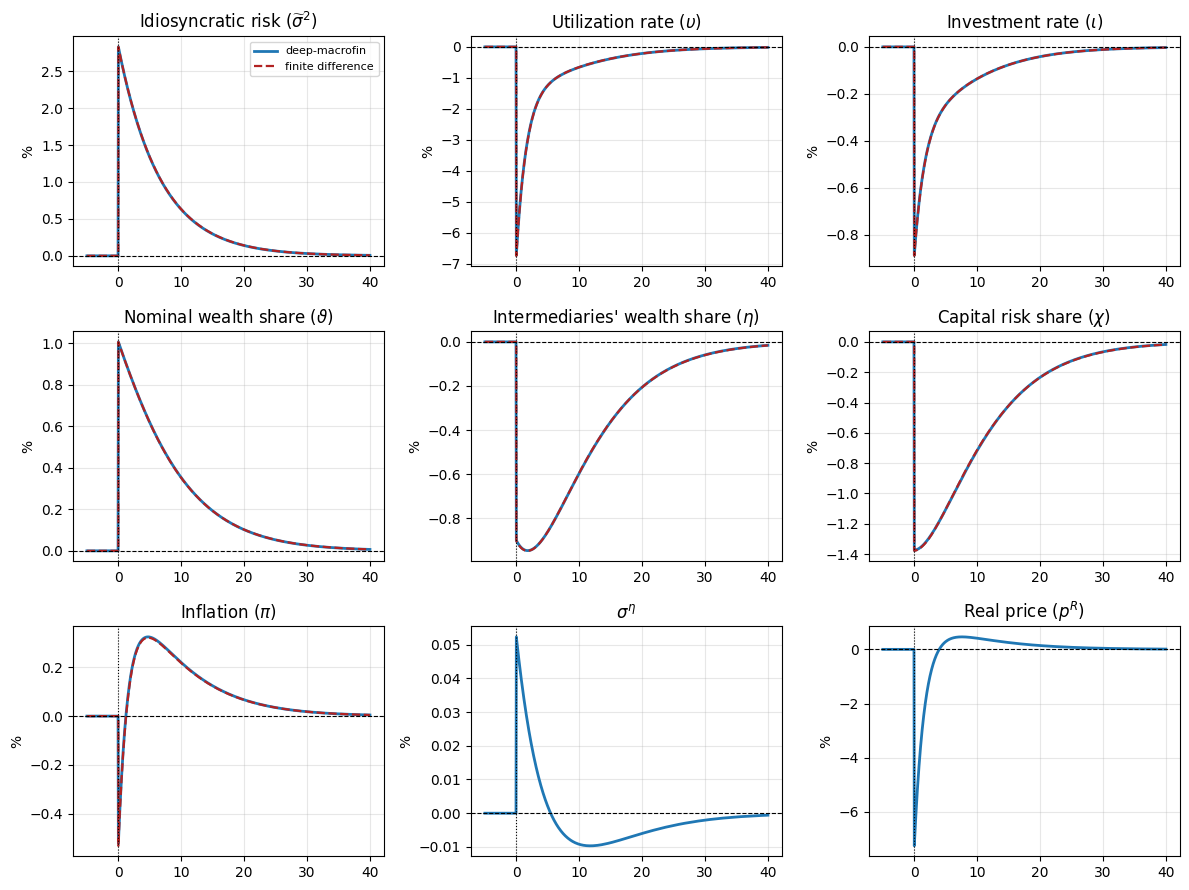

In [17]:
# Passive solve, refining the baseline rather than starting from noise.  The
# rate has to decay: held at 1e-3 it walks away from the warm start, held at
# 1e-4 it stalls an order of magnitude short of what the steady state needs.
model = get_model(
    MODEL_PATH,
    model_size=[64, 64, 64, 64],
    batch_size=2000,
    num_epochs=20000,
    lr=3e-4,
    lr_end=1e-6,
    eta_range=STATE_DOMAIN["eta"],
    u_range=STATE_DOMAIN["u"],
    warm_start_path=BASELINE_PATH,
)

check_state_domain(model)
irf = simulate_irf(model, shock=dZ, horizon=T_irf, dt=dt_irf, pre_shock=ap)
plot_lf_irf(irf, MODEL_PATH, reference=finite_difference_irf())